Phase Diagram Generator for Systems of Differential Equations
Enter a system of differential equations:

Format: Two equations of the form:
  dx/dt = f(x, y)
  dy/dt = g(x, y)

Examples:
  Lotka-Volterra (Predator-Prey):
    dx/dt = x - 0.5*x*y
    dy/dt = -y + 0.5*x*y

  Pendulum:
    dx/dt = y
    dy/dt = -sin(x)

  Van der Pol Oscillator:
    dx/dt = y
    dy/dt = -x + (1 - x**2)*y

Available functions:
  sin, cos, tan, exp, log, sqrt, abs
  arcsin, arccos, arctan, sinh, cosh, tanh
  Mathematical operators: +, -, *, /, **

Enter dx/dt = -x-4*y-4
Enter dy/dt = x-y-6

Enter x range (format: min, max) or press Enter for default [-5, 5]: 
Enter y range (format: min, max) or press Enter for default [-5, 5]: 

System of Differential Equations
dx/dt = -x-4*y-4
dy/dt = x-y-6

At test point (0.0, 0.0):
  dx/dt = -4.000000
  dy/dt = -6.000000
  Velocity magnitude = 7.211103

Enter initial conditions for solution trajectories:
You can add multiple initial conditions
Do you want to add initial 

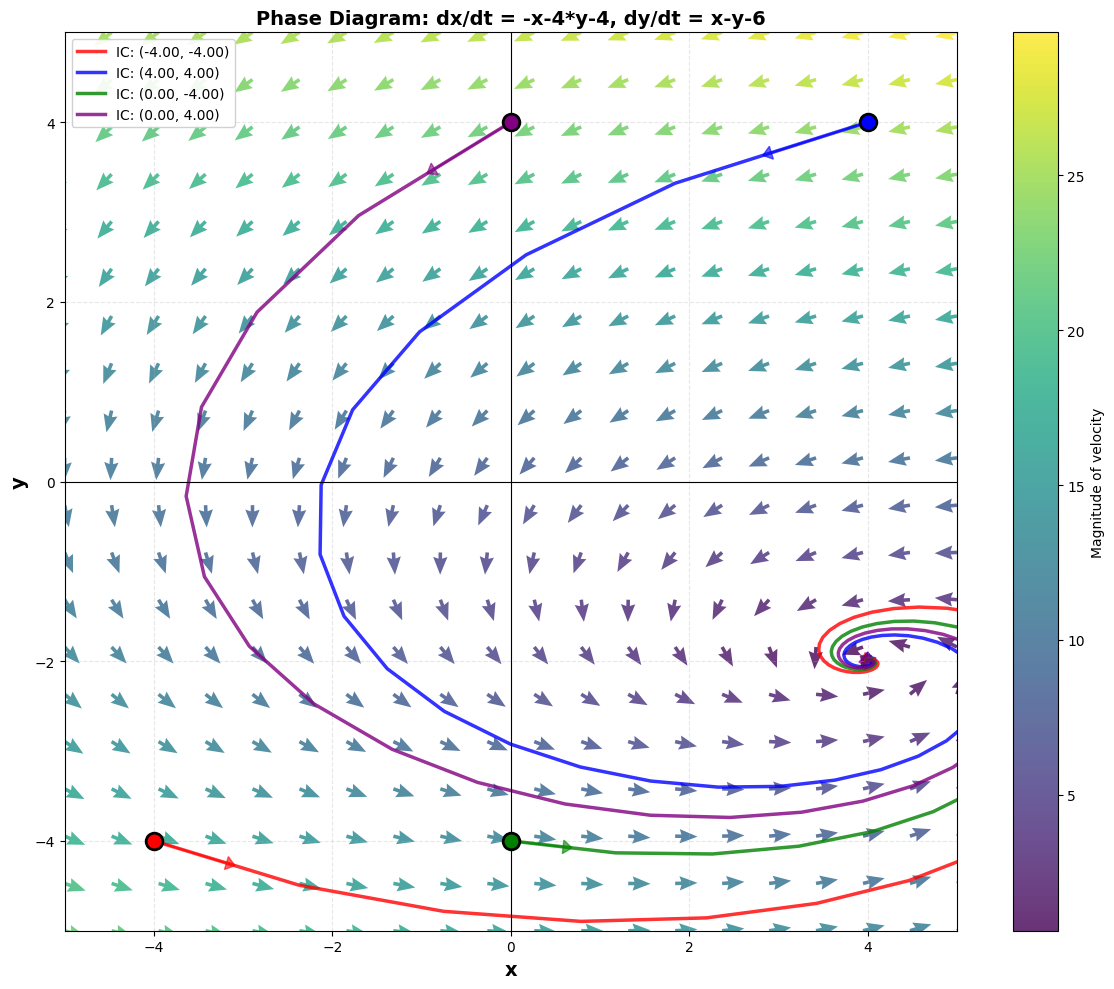

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

def evaluate_function(func_str, x, y):
    """Safely evaluate the user's function"""
    try:
        # Create a safe namespace with numpy functions
        namespace = {
            'x': x, 'y': y,
            'sin': np.sin, 'cos': np.cos, 'tan': np.tan,
            'exp': np.exp, 'log': np.log, 'sqrt': np.sqrt,
            'pi': np.pi, 'e': np.e,
            'abs': np.abs, 'arcsin': np.arcsin, 'arccos': np.arccos,
            'arctan': np.arctan, 'sinh': np.sinh, 'cosh': np.cosh,
            'tanh': np.tanh
        }
        result = eval(func_str, {"__builtins__": {}}, namespace)
        return result
    except Exception as e:
        print(f"Error evaluating function: {e}")
        return None

def solve_system_odeint(func_str_x, func_str_y, x0, y0, t_span):
    """Solve the system of ODEs using scipy's odeint"""
    try:
        def system(state, t):
            x, y = state
            dx_dt = evaluate_function(func_str_x, x, y)
            dy_dt = evaluate_function(func_str_y, x, y)

            if dx_dt is None or dy_dt is None:
                return [0, 0]

            return [dx_dt, dy_dt]

        # Solve the ODE
        solution = odeint(system, [x0, y0], t_span)
        x_sol = solution[:, 0]
        y_sol = solution[:, 1]

        return x_sol, y_sol
    except Exception as e:
        print(f"Error solving system: {e}")
        return None, None

def plot_phase_diagram(func_str_x, func_str_y, x_min, x_max, y_min, y_max, initial_conditions, t_span):
    """Generate and plot the phase diagram for a system of ODEs"""

    fig, ax = plt.subplots(figsize=(12, 10))

    # Create grid of points for vector field
    x_range = np.linspace(x_min, x_max, 20)
    y_range = np.linspace(y_min, y_max, 20)
    X, Y = np.meshgrid(x_range, y_range)

    # Calculate direction vectors
    U = evaluate_function(func_str_x, X, Y)
    V = evaluate_function(func_str_y, X, Y)

    if U is None or V is None:
        ax.text(0.5, 0.5, 'Invalid function!', ha='center', va='center',
                fontsize=16, color='red', transform=ax.transAxes)
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        plt.show()
        return

    # Convert to arrays if they're scalars
    if np.isscalar(U):
        U = np.full_like(X, U)
    if np.isscalar(V):
        V = np.full_like(X, V)

    # Normalize the vectors for better visualization
    magnitude = np.sqrt(U**2 + V**2)
    magnitude[magnitude == 0] = 1  # Avoid division by zero
    U_norm = U / magnitude * 0.3
    V_norm = V / magnitude * 0.3

    # Plot the vector field
    ax.quiver(X, Y, U_norm, V_norm, magnitude, cmap='viridis',
              alpha=0.8, scale=12, width=0.004, headwidth=4, headlength=5)

    # Plot solution trajectories for each initial condition
    colors = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'cyan']

    for idx, (x0, y0) in enumerate(initial_conditions):
        x_sol, y_sol = solve_system_odeint(func_str_x, func_str_y, x0, y0, t_span)

        if x_sol is not None and y_sol is not None:
            color = colors[idx % len(colors)]

            # Plot the trajectory
            ax.plot(x_sol, y_sol, '-', color=color, linewidth=2.5, alpha=0.8,
                   label=f'IC: ({x0:.2f}, {y0:.2f})')

            # Mark initial point
            ax.plot(x0, y0, 'o', color=color, markersize=12,
                   markeredgecolor='black', markeredgewidth=2, zorder=5)

            # Mark direction with arrows along the trajectory
            for i in range(0, len(x_sol)-1, max(1, len(x_sol)//5)):
                dx = x_sol[i+1] - x_sol[i]
                dy = y_sol[i+1] - y_sol[i]
                ax.arrow(x_sol[i], y_sol[i], dx*0.5, dy*0.5,
                        head_width=0.15, head_length=0.1, fc=color, ec=color, alpha=0.6)

    # Find and plot equilibrium points (where both derivatives are zero)
    print("\nSearching for equilibrium points...")
    equilibrium_points = []

    # Sample points to find approximate equilibria
    x_sample = np.linspace(x_min, x_max, 15)
    y_sample = np.linspace(y_min, y_max, 15)

    for x in x_sample:
        for y in y_sample:
            u = evaluate_function(func_str_x, x, y)
            v = evaluate_function(func_str_y, x, y)

            if u is not None and v is not None:
                if abs(u) < 0.1 and abs(v) < 0.1:
                    # Check if this is a new equilibrium point
                    is_new = True
                    for eq_x, eq_y in equilibrium_points:
                        if abs(x - eq_x) < 0.5 and abs(y - eq_y) < 0.5:
                            is_new = False
                            break

                    if is_new:
                        equilibrium_points.append((x, y))
                        ax.plot(x, y, 'r*', markersize=20, markeredgecolor='darkred',
                               markeredgewidth=1.5, zorder=6)

    if equilibrium_points:
        print(f"Found {len(equilibrium_points)} equilibrium point(s):")
        for x, y in equilibrium_points:
            print(f"  ({x:.4f}, {y:.4f})")
    else:
        print("No equilibrium points found in the given region")

    # Set labels and title
    ax.set_xlabel('x', fontsize=14, fontweight='bold')
    ax.set_ylabel('y', fontsize=14, fontweight='bold')
    ax.set_title(f'Phase Diagram: dx/dt = {func_str_x}, dy/dt = {func_str_y}',
                fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.axhline(y=0, color='k', linewidth=0.8)
    ax.axvline(x=0, color='k', linewidth=0.8)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.legend(loc='best', fontsize=10, framealpha=0.9)

    # Add colorbar for magnitude
    cbar = plt.colorbar(ax.collections[0], ax=ax, label='Magnitude of velocity')

    plt.tight_layout()
    plt.show()

def print_phase_info(func_str_x, func_str_y, x_test, y_test):
    """Print information about the system at a test point"""
    print("\n" + "=" * 70)
    print("System of Differential Equations")
    print("=" * 70)
    print(f"dx/dt = {func_str_x}")
    print(f"dy/dt = {func_str_y}")
    print("=" * 70)

    dx_dt = evaluate_function(func_str_x, x_test, y_test)
    dy_dt = evaluate_function(func_str_y, x_test, y_test)

    print(f"\nAt test point ({x_test}, {y_test}):")
    print(f"  dx/dt = {dx_dt:.6f}")
    print(f"  dy/dt = {dy_dt:.6f}")
    print(f"  Velocity magnitude = {np.sqrt(dx_dt**2 + dy_dt**2):.6f}")
    print("=" * 70)

# Main program
print("Phase Diagram Generator for Systems of Differential Equations")
print("=" * 70)
print("Enter a system of differential equations:")
print("\nFormat: Two equations of the form:")
print("  dx/dt = f(x, y)")
print("  dy/dt = g(x, y)")
print("\nExamples:")
print("  Lotka-Volterra (Predator-Prey):")
print("    dx/dt = x - 0.5*x*y")
print("    dy/dt = -y + 0.5*x*y")
print("\n  Pendulum:")
print("    dx/dt = y")
print("    dy/dt = -sin(x)")
print("\n  Van der Pol Oscillator:")
print("    dx/dt = y")
print("    dy/dt = -x + (1 - x**2)*y")
print("\nAvailable functions:")
print("  sin, cos, tan, exp, log, sqrt, abs")
print("  arcsin, arccos, arctan, sinh, cosh, tanh")
print("  Mathematical operators: +, -, *, /, **")
print("=" * 70)

# Get differential equations
func_input_x = input("\nEnter dx/dt = ")
func_input_y = input("Enter dy/dt = ")

# Get x range
while True:
    x_range_input = input("\nEnter x range (format: min, max) or press Enter for default [-5, 5]: ")
    if x_range_input.strip():
        try:
            parts = x_range_input.split(',')
            if len(parts) != 2:
                raise ValueError
            x_min, x_max = map(float, parts)
            if x_min >= x_max:
                print("Error: min must be less than max")
                continue
            break
        except:
            print("Invalid range format!")
            print("Example: -10, 10  or  0, 5")
            continue
    else:
        x_min, x_max = -5, 5
        break

# Get y range
while True:
    y_range_input = input("Enter y range (format: min, max) or press Enter for default [-5, 5]: ")
    if y_range_input.strip():
        try:
            parts = y_range_input.split(',')
            if len(parts) != 2:
                raise ValueError
            y_min, y_max = map(float, parts)
            if y_min >= y_max:
                print("Error: min must be less than max")
                continue
            break
        except:
            print("Invalid range format!")
            print("Example: -10, 10  or  0, 5")
            continue
    else:
        y_min, y_max = -5, 5
        break

# Print system info at a test point
test_x = (x_min + x_max) / 2
test_y = (y_min + y_max) / 2
print_phase_info(func_input_x, func_input_y, test_x, test_y)

# Get initial conditions
initial_conditions = []
print("\nEnter initial conditions for solution trajectories:")
print("You can add multiple initial conditions")

add_ic = input("Do you want to add initial conditions? (yes/no): ").strip().lower()

while add_ic in ['yes', 'y']:
    while True:
        ic_input = input("Format (x0, y0): ")
        try:
            parts = ic_input.split(',')
            if len(parts) != 2:
                raise ValueError

            namespace = {
                'sin': np.sin, 'cos': np.cos, 'tan': np.tan,
                'exp': np.exp, 'log': np.log, 'sqrt': np.sqrt,
                'pi': np.pi, 'e': np.e, 'abs': abs,
                'arcsin': np.arcsin, 'arccos': np.arccos,
                'arctan': np.arctan, 'sinh': np.sinh,
                'cosh': np.cosh, 'tanh': np.tanh
            }

            x0 = float(eval(parts[0].strip(), {"__builtins__": {}}, namespace))
            y0 = float(eval(parts[1].strip(), {"__builtins__": {}}, namespace))

            initial_conditions.append((x0, y0))
            print(f"Added initial condition: ({x0}, {y0})")
            break
        except:
            print("Invalid format!")
            print("Example: 0, 1  or  -2, 3  or  pi/2, sqrt(2)")
            continue

    add_ic = input("Add another initial condition? (yes/no): ").strip().lower()

# If no initial conditions provided, use some default ones
if not initial_conditions:
    print("\nNo initial conditions provided. Using default initial conditions...")
    initial_conditions = [
        (x_min + 1, y_min + 1),
        (x_max - 1, y_max - 1),
        ((x_min + x_max) / 2, y_min + 1),
        ((x_min + x_max) / 2, y_max - 1),
    ]

# Get time span
while True:
    try:
        t_end = float(input("\nEnter the time span for integration (e.g., 100): "))
        if t_end <= 0:
            print("Error: Time span must be positive")
            continue
        break
    except:
        print("Invalid input! Please enter a positive number.")
        continue

t_span = np.linspace(0, t_end, 1000)

# Plot the phase diagram
plot_phase_diagram(func_input_x, func_input_y, x_min, x_max, y_min, y_max, initial_conditions, t_span)